,Iteración,t,g(t)=E(t)-0.5,g'(t)
0,1,1.66000000,-5.55631857e-04,-1.76483211e-01
1,2,1.65685164,1.47252105e-06,-1.76950922e-01
2,3,1.65685997,0.00000000e+00,-1.76950922e-01


Instante tm tal que E(tm) = E0/2: tm = 1.65685997
E(tm) ≈ 0.50000000


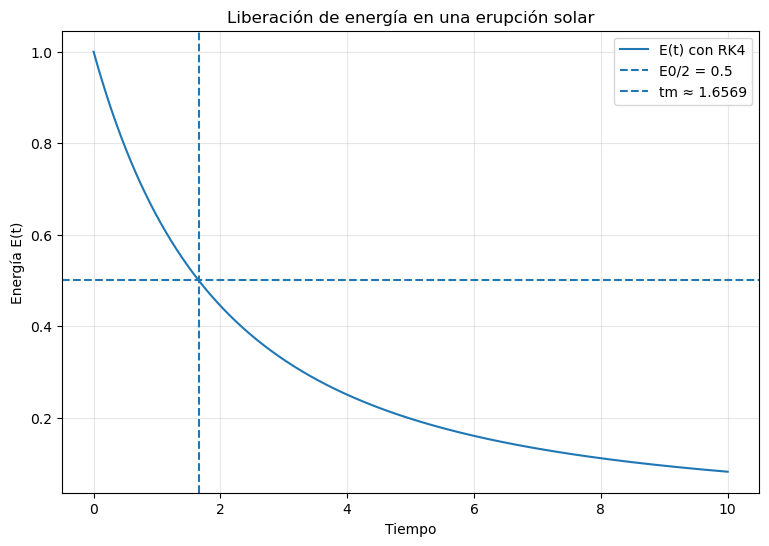

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Parámetros del problema
n = 1.5
E0 = 1.0
t0 = 0.0
tf = 10.0
h = 0.01

#Ec. dif que describe la disminución de la energía en el tiempo
def f(t, E):
    return -alpha * E**n


# RK4 clásico
def rk4(f, t0, tf, y0, h):
    t_vals = np.arange(t0, tf + h, h)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0

    for i in range(len(t_vals) - 1):
        t = t_vals[i]
        y = y_vals[i]

        k1 = f(t, y)
        k2 = f(t + h/2, y + (h/2)*k1)
        k3 = f(t + h/2, y + (h/2)*k2)
        k4 = f(t + h, y + h*k3)

        y_vals[i+1] = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

    return t_vals, y_vals

# Resolver la ODE
t_vals, E_vals = rk4(f, t0, tf, E0, h)


# Interpolación lineal para E(t)
def E_interp(t):
    return np.interp(t, t_vals, E_vals)

# Usamos Newton-Raphson para encontrar el tiempo
# en el que la energía de la erupción cae a la mitad

def g(t):
    return E_interp(t) - 0.5

# cálculo de la derivada numérica de g(t)
def dg(t, delta=1e-5):
    return (g(t + delta) - g(t - delta)) / (2 * delta)

def newton_raphson(x0, tol=1e-10, max_iter=50):
    x = x0
    historial = []

    for i in range(max_iter):
        gx = g(x)
        dgx = dg(x)

        historial.append([i + 1, x, gx, dgx])

        if abs(gx) < tol:
            return x, historial

        if abs(dgx) < 1e-14:
            raise ValueError("La derivada es demasiado pequeña; Newton-Raphson falla.")

        x = x - gx / dgx

    raise ValueError("Newton-Raphson no convergió en el número máximo de iteraciones.")


# estimación inicial del tiempo donde E ≈ 0.5
indice = np.argmin(np.abs(E_vals - 0.5))
x0_nr = t_vals[indice]

tm, historial_nr = newton_raphson(x0_nr)


# Tabla 

tabla_nr = pd.DataFrame(historial_nr, columns=[
    "Iteración", "t", "g(t)=E(t)-0.5", "g'(t)"
])

display(
    tabla_nr.style.format({
        "t": "{:.8f}",
        "g(t)=E(t)-0.5": "{:.8e}",
        "g'(t)": "{:.8e}"
    }).background_gradient(cmap="RdPu")
)


# Resultado 

print(f"Instante tm tal que E(tm) = E0/2: tm = {tm:.8f}")
print(f"E(tm) ≈ {E_interp(tm):.8f}")


# Gráfica
plt.figure(figsize=(9,6))
plt.plot(t_vals, E_vals, label="E(t) con RK4")
plt.axhline(0.5, linestyle="--", label="E0/2 = 0.5")
plt.axvline(tm, linestyle="--", label=f"tm ≈ {tm:.4f}")

plt.xlabel("Tiempo")
plt.ylabel("Energía E(t)")
plt.title("Liberación de energía en una erupción solar")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()